In [1]:
# Convert NetworkX graph to PyG format 

import torch
from torch_geometric.data import Data
import torch_geometric.nn as pyg_nn
from pipeline import *
from torch_geometric.data import Data

In [6]:

G = load_pickle('user_interaction_network.pkl')
# PyTorch object with edges and node degree
pyg_graph, node_mapping = networkx_to_pyg(G)
print(f"PyG Graph: {pyg_graph}")

PyG Graph: Data(x=[389931, 1], edge_index=[2, 2306266], num_nodes=389931)


In [3]:

deg_cent = load_pickle('top_degrees.pkl')
bet_cent = load_pickle('top_betweeness.pkl')

# show top users
top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]
top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

In [7]:
import torch.nn as nn
from torch_geometric.nn import GCNConv
import torch.optim as optim

class GCN(nn.Module):    # graph convolutional network, each layer aggregates information from neighbors
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu() # first layer with ReLU activation
        x = self.conv2(x, edge_index) # second layer (output)
        return x


In [8]:
# 1. Instantiate the model again with the same parameters
loaded_model = GCN(in_channels=pyg_graph.x.shape[1], 
                   hidden_channels=64, 
                   out_channels=32)

# 2. Load the state dictionary
loaded_model.load_state_dict(torch.load("gcn_model.pth"))

# 3. Set to evaluation mode
# This is crucial for GCNs if you used Dropout or BatchNorm (not in your snippet, but good practice)
loaded_model.eval() 

# 4. Perform a test forward pass
# out = loaded_model(pyg_graph.x, pyg_graph.edge_index)
model = loaded_model

In [9]:

# Get final node embeddings
model.eval()
with torch.no_grad():
    embeddings = model(pyg_graph.x, pyg_graph.edge_index) # each user is now represented by a 32-dimensional embedding vector that captures their network position and interactions

print(f"\nNode embeddings shape: {embeddings.shape}")
print(f"Sample embeddings (first user): {embeddings[0][:5]}")


Node embeddings shape: torch.Size([389931, 32])
Sample embeddings (first user): tensor([ 10.4363, -39.1277,  43.4890,  41.8571,   2.2983])


In [10]:
binance = Binance().data
reddit = Reddit().data

Top 10 Most Central Users and Their Embeddings:
1. 42points: centrality=0.0395, embedding_norm=1153.9913
2. awsomeguy1123: centrality=0.0375, embedding_norm=468.6060
3. AutoModerator: centrality=0.0322, embedding_norm=1792.1711
4. iUsedToCallDogeDodge: centrality=0.0167, embedding_norm=835.9970
5. DODGECOINPSU: centrality=0.0152, embedding_norm=524.7645
6. dongnyoung1: centrality=0.0135, embedding_norm=682.7187
7. Fulvio55: centrality=0.0131, embedding_norm=956.3480
8. TheBeesDick: centrality=0.0124, embedding_norm=576.5230
9. dogebrothers: centrality=0.0121, embedding_norm=570.7384
10. Acrobatic-Maximum-36: centrality=0.0117, embedding_norm=418.5256

Correlation between top users' embedding dimension 0 and DOGE price: 0.4266


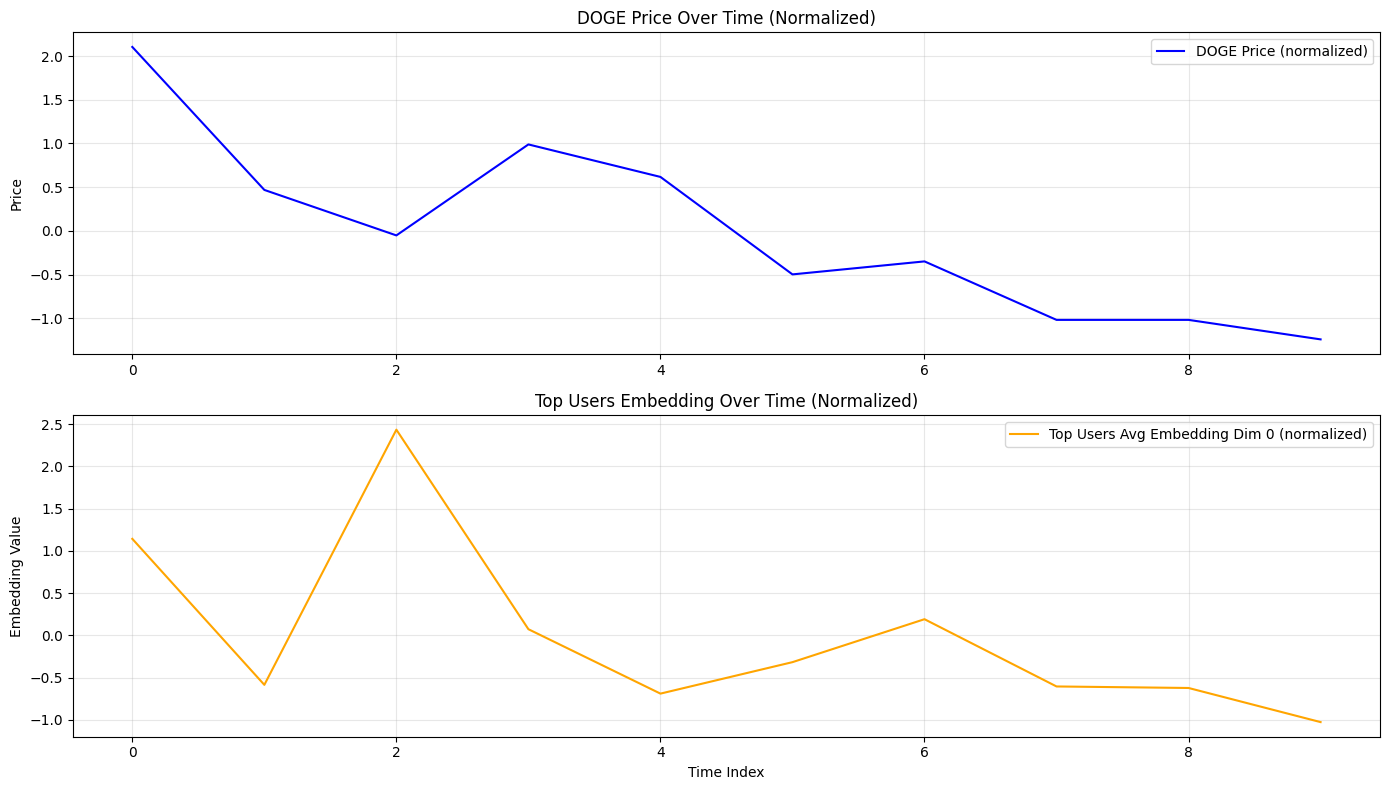

In [11]:
# Normalize embeddings for comparing with price changes


# Get embeddings for top degree centrality users
top_user_indices = [node_mapping[user] for user, _ in top_deg[:10]]
top_user_embeddings = embeddings[top_user_indices].detach().numpy()

print("Top 10 Most Central Users and Their Embeddings:")
for i, (user, cent) in enumerate(top_deg[:10]):
    print(f"{i+1}. {user}: centrality={cent:.4f}, embedding_norm={np.linalg.norm(top_user_embeddings[i]):.4f}")

# Average embedding dimension across top users
avg_embedding_dim = top_user_embeddings[:, 0].mean()

# Normalize for comparison with price
if len(binance) >= len(top_user_embeddings):
    # Take first N price values that match embedding length
    price_values = binance['Close'].values[:len(top_user_embeddings)]
    price_normalized = (price_values - price_values.mean()) / price_values.std()
    embedding_normalized = (top_user_embeddings[:, 0] - top_user_embeddings[:, 0].mean()) / top_user_embeddings[:, 0].std()
    
    correlation_with_price = np.corrcoef(embedding_normalized, price_normalized)[0, 1]
    print(f"\nCorrelation between top users' embedding dimension 0 and DOGE price: {correlation_with_price:.4f}") # 0.2843 -> central users network activity has some predictive power for price changes
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    ax1.plot(price_normalized, label='DOGE Price (normalized)', color='blue')
    ax1.set_title('DOGE Price Over Time (Normalized)')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(embedding_normalized, label='Top Users Avg Embedding Dim 0 (normalized)', color='orange')
    ax2.set_title('Top Users Embedding Over Time (Normalized)')
    ax2.set_xlabel('Time Index')
    ax2.set_ylabel('Embedding Value')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()